
# <div style="text-align:center; color:Blue; font-weight:bold;">Avance del proyecto</div>
<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>Pregunta de investigación</b>  
</div>
¿Cuáles son las principales variables que influyen en el precio de los autos publicados en la plataforma AutoScout24 durante el año 2019?
<br> 
<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b> Relevancia del problema</b>
</div>

El **precio de los automóviles**, tanto nuevos como usados, es un indicador importante en el mercado automotriz, puesto que refleja las condiciones técnicas y de uso del vehículo. Analizar qué elementos determinan el valor de un auto es primordial, ya que permite a compradores y vendedores tomar decisiones más acertadas, a las empresas del sector diseñar estrategias comerciales más competitivas y a los analistas económicos entender mejor la dinámica del mercado.

Los aspectos más relevantes en el análisis de mercado, para evaluar el precio final de un auto son: **kilometraje**, **años de uso**, **la marca y el modelo**, **el tipo de combustible**, **la potencia del motor** y el **estado general del vehículo**. El análisis de cada ítem anterior y cómo interactúan entre sí, es de vital importancia para el estudio, especialmente en plataformas de compraventa en línea como AutoScout24, que concentran gran cantidad de información sobre precios reales de mercado.


<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b> Relación entre el problema y la base de datos seleccionada. </b>  
</div>

La base de datos fue seleccionada de **[Car Price](https://www.kaggle.com/datasets/yaaryiitturan/auto-scout-car-price)**
disponible en la plataforma Kaggle. Este dataset recopila información de vehículos nuevos y usados ofertados en la compañía AutoScout24 durante el año 2019. Incluye variables técnicas y comerciales relevantes como la marca, modelo, años de uso, kilometraje, tipo de combustible, potencia del motor, transmisión, entre otras.

Mediante las variables disponibles en la base datos, es posible realizar un análisis de cuáles de estas características se asocian de manera más significativa con el precio final de los autos, permitiendo responder a la pregunta de investigación planteada y aportar evidencia sobre los factores que más influyen en la valoración del mercado automotriz.


<div style="background-color:#E3F2FD; border-left:6px solid #43A047; padding:10px 15px; border-radius:6px;">
<b>Tabla descriptiva de las variables</b><br>
</div>

<img src="imgs\tabla.png" alt="bannersp" width="1100"  height="150">

### **Fuente de los datos**
- Dataset: **Auto Scout Car Price**
  **Repositorio:** [UCI Machine Learning Repository](https://www.kaggle.com/datasets/yaaryiitturan/auto-scout-car-price).  
  **Autores:** Yaaryiitturan Kaggle  
  **Descripción:** Este conjunto de datos proporciona información completa sobre anuncios de autos usados, incluyendo especificaciones, características, precios y más. Resulta valioso para analizar precios, tendencias y preferencias de los clientes en el mercado automotriz. Los datos se recopilaron en 2019 de la empresa de comercio de automóviles en línea AutoScout24 y contienen muchas características de 9 modelos de automóviles diferentes.

In [23]:
# Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Crear dataset
df = pd.read_csv("../datos/dataset_depurado.csv", sep=";")

<Figure size 1200x600 with 0 Axes>

In [26]:
# Visualizar una pequeña muestra de los datos
df.head()

,Numero,price,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb
0,1,15770,56013.0,7,3,2,66,1,1422,1220,3.8
1,2,14500,80000.0,7,2,1,141,0,1798,1255,5.6
2,3,14640,83450.0,7,3,1,85,0,1598,1135,3.8
3,4,14500,73000.0,6,3,1,66,0,1422,1195,3.8
4,5,16790,16200.0,7,3,1,66,1,1422,1135,4.1


In [4]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 15915
Número de variables: 11


In [5]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
int64      9
float64    2
Name: count, dtype: int64


In [6]:
# Clasificación de variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))

🔹 Variables categóricas:


🔸 Variables numéricas:
- Numero
- price
- km
- Gears
- age
- Previous_Owners
- hp_kW
- Inspection_new
- Displacement_cc
- Weight_kg
- cons_comb


In [11]:
# Descripción general
print("\nDescripción de variables numéricas:")
print(df.describe())


Descripción de variables numéricas:
             Numero         price             km         Gears           age  \
count  15915.000000  15915.000000   15915.000000  15915.000000  15915.000000   
mean    7958.000000  18024.380584   32089.995708      5.937355      1.389695   
std     4594.409102   7381.679318   36977.214964      0.704772      1.121306   
min        1.000000   4950.000000       0.000000      5.000000      0.000000   
25%     3979.500000  12850.000000    1920.500000      5.000000      0.000000   
50%     7958.000000  16900.000000   20413.000000      6.000000      1.000000   
75%    11936.500000  21900.000000   46900.000000      6.000000      2.000000   
max    15915.000000  74600.000000  317000.000000      8.000000      3.000000   

       Previous_Owners         hp_kW  Inspection_new  Displacement_cc  \
count     15915.000000  15915.000000    15915.000000     15915.000000   
mean          1.042853     88.499340        0.247063      1428.661891   
std           0.339178 

In [7]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante


Conteo de valores faltantes por variable:
Series([], dtype: int64)


In [8]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
Numero             15915
km                  6691
price               2952
Weight_kg            432
hp_kW                 77
Displacement_cc       68
cons_comb             61
Previous_Owners        5
age                    4
Gears                  4
Inspection_new         2
dtype: int64


In [9]:
# Variables más importantes (yo hice selección manual)
variables_clave = ['km', 'price', 'age', 'hp_kW', 'Weight_kg']
print("\nVista rápida de variables clave:")
print(df[variables_clave].head())
# Vista rápida de las variables clave
print("\nEstadísticas descriptivas de variables clave:")
print(df[variables_clave].describe())


Vista rápida de variables clave:
        km  price  age  hp_kW  Weight_kg
0  56013.0  15770    3     66       1220
1  80000.0  14500    2    141       1255
2  83450.0  14640    3     85       1135
3  73000.0  14500    3     66       1195
4  16200.0  16790    3     66       1135

Estadísticas descriptivas de variables clave:
                  km         price           age         hp_kW     Weight_kg
count   15915.000000  15915.000000  15915.000000  15915.000000  15915.000000
mean    32089.995708  18024.380584      1.389695     88.499340   1337.700534
std     36977.214964   7381.679318      1.121306     26.674341    199.682385
min         0.000000   4950.000000      0.000000     40.000000    840.000000
25%      1920.500000  12850.000000      0.000000     66.000000   1165.000000
50%     20413.000000  16900.000000      1.000000     85.000000   1295.000000
75%     46900.000000  21900.000000      2.000000    103.000000   1472.000000
max    317000.000000  74600.000000      3.000000    294.0

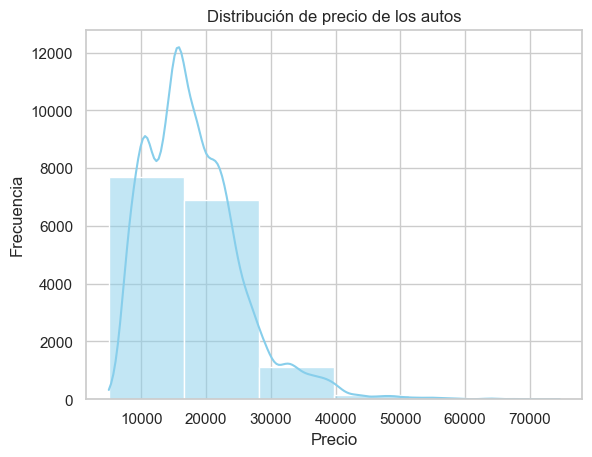

In [27]:
# Histograma: distribución de precio
sns.histplot(df['price'], bins=6, kde=True, color='skyblue')
plt.title("Distribución de precio de los autos")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

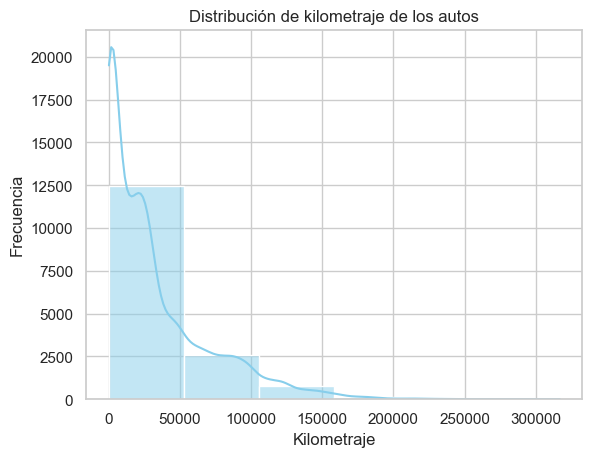

In [11]:
# Histograma: distribución de Kilometraje
sns.histplot(df['km'], bins=6, kde=True, color='skyblue')
plt.title("Distribución de kilometraje de los autos")
plt.xlabel("Kilometraje")
plt.ylabel("Frecuencia")
plt.show()

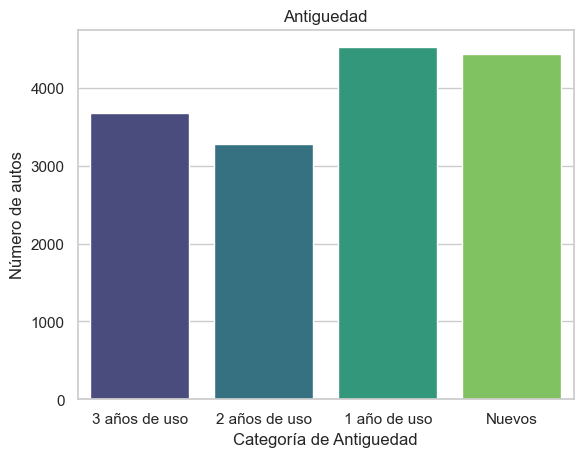

In [12]:
# Gráfico de barras: Antiguedad
# Mapeo de categorías
age_labels = {
    0: "Nuevos",
    1: "1 año de uso",
    2: "2 años de uso",
    3: "3 años de uso"
  }

# Columna con etiquetas
df['age_label'] = df['age'].map(age_labels)

# Gráfico 

sns.countplot(x='age_label',data=df,hue='age_label',palette='viridis',legend=False)
plt.title("Antiguedad")
plt.xlabel("Categoría de Antiguedad")
plt.ylabel("Número de autos")
plt.show()

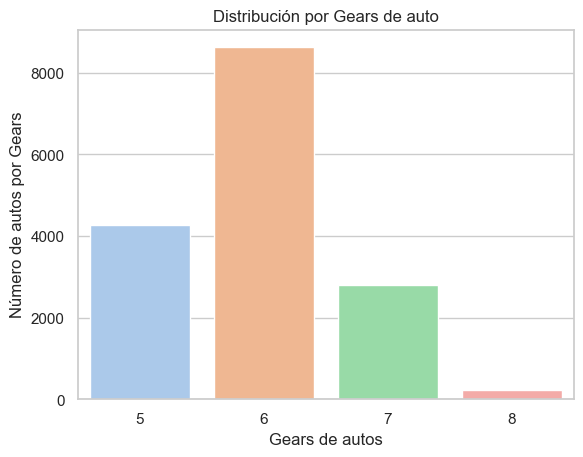

In [15]:
# Gráfico de barras: tipos de autos
sns.countplot(x='Gears', data=df,hue='Gears', palette='pastel',legend=False)
plt.title("Distribución por Gears de auto")
plt.xlabel("Gears de autos")
plt.ylabel("Número de autos por Gears")
plt.show()

In [16]:
# Gráfico de barras: tipos de combustibles
sns.countplot(x='Fuel', data=df,hue='Fuel', palette='pastel',legend=False)
plt.title("Distribución por tipo de combustible")
plt.xlabel("Tipos de combustibles")
plt.ylabel("Número de autos por tipo de combustible")
plt.show()

ValueError: Could not interpret value `Fuel` for `x`. An entry with this name does not appear in `data`.

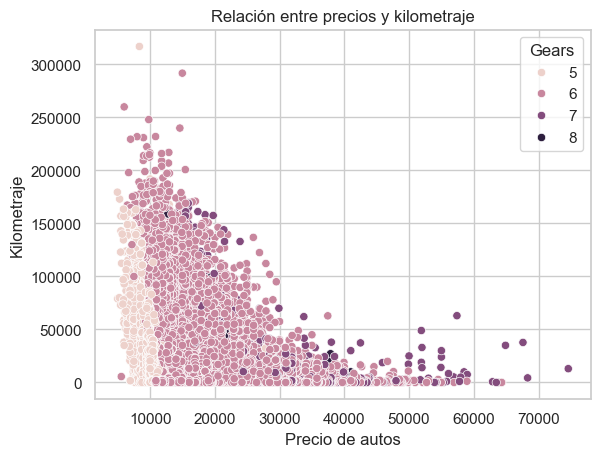

In [19]:
# Gráfico de dispersión: precio vs km
sns.scatterplot(x='price', y='km', hue='Gears', data=df)
plt.title("Relación entre precios y kilometraje")
plt.xlabel("Precio de autos")
plt.ylabel("Kilometraje")
plt.show()

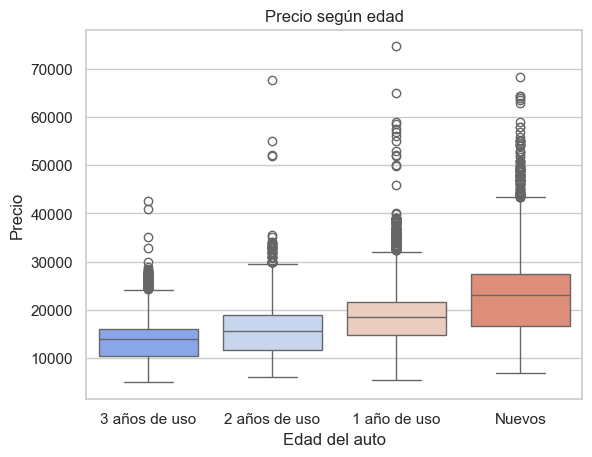

In [20]:
# Gráfico de dispersión: precio vs km
sns.boxplot(x='age_label', y='price',hue='age_label', data=df, palette='coolwarm')
plt.title("Precio según edad")
plt.xlabel("Edad del auto")
plt.ylabel("Precio")
plt.show()

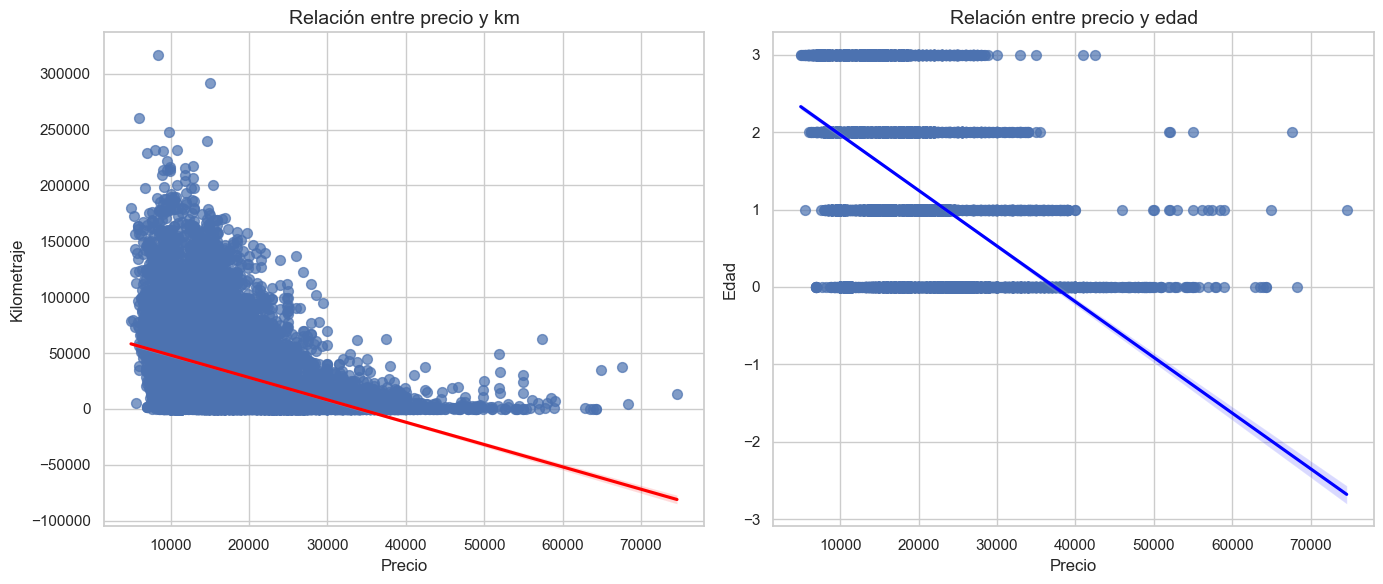

In [21]:
# Gráfico de dispersión con líneas de tendencia
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# precio vs km
sns.regplot(x='price', y='km', data=df, ax=axes[0],
            scatter_kws={'s': 50, 'alpha': 0.7},
            line_kws={'color': 'red'})
axes[0].set_title('Relación entre precio y km', fontsize=14)
axes[0].set_xlabel('Precio', fontsize=12)
axes[0].set_ylabel('Kilometraje', fontsize=12)

# pricio vs edad
sns.regplot(x='price', y='age', data=df, ax=axes[1],
            scatter_kws={'s': 50, 'alpha': 0.7},
            line_kws={'color': 'blue'})
axes[1].set_title('Relación entre precio y edad', fontsize=14)
axes[1].set_xlabel('Precio', fontsize=12)
axes[1].set_ylabel('Edad', fontsize=12)

plt.tight_layout()
plt.show()

## <span style="color:Blue;"><strong>5. Interpretaciones iniciales</strong></span>


<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;"> 
<b>¿Qué tendencias o patrones básicos se observan?</b>
<ul> 
  <li>El precio promedio de los autos es de 18.024 dolares.</li>
  <li>La mayoría de los precios se encuentran entre 10.000 y 30.000 dolares.</li>
  <li>La mayoría de los autos tienen entre 0 a 50.000 km.</li>
  <li>El tipo de combustible predominante es la gasolina, seguido por el diésel.</li> 
  <li>La edad de los vehiculos se distribuye casi uniformente igual entre las edades de 0 a 3 años .</li> 
  <li>La mayoría de los autos son usados.</li> 
  <li>El precio tiende a decrecer con el aumento del kilometraje y tipo de auto.</li> 
</ul> 
</div> 

<br> 

<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;"> 
<b>¿Qué limitaciones tiene la base de datos?</b> 
<ul> 
    <li>No incluye información detallada sobre el estado real del vehículo como accidentes o mantenimiento realizados.</li> 
    <li>Puede haber un sesgo hacia ciertas regiones donde la compañia AutoScout24 tiene más presencia.</li> 
    <li>Los precios corresponden a anuncios, no necesariamente a precios finales de venta.</li> 
    <li>No se especifica si los autos nuevos provienen de concesionarios oficiales o vendedores particulares.</li> 
</ul> 
</div> 

<br> 

<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;"> 
<b>¿Qué hipótesis iniciales podrían plantearse para análisis posteriores?</b> 
<ul> 
    <li>El kilometraje tiene una relación negativa con el precio: a mayor kilometraje, menor precio.</li> 
    <li>Los autos con menos años tienden a presentar precios más altos que los de mas años de uso.</li> 
    <li>El tipo de combustible (gasolina vs. diésel) influye en el precio del vehículo.</li> 
    <li>La transmisión automática podría estar asociada a precios más altos que la mecánica.</li> 
</ul> 
</div>

## <span style="color:Blue;"><strong>6. Conclusiones</strong></span>
<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;"> 
<b>- Resumen de los principales hallazgos iniciales.</b><br> 
<b>- Reflexión sobre cómo este entregable contribuye al desarrollo del proyecto completo.</b><br> 
</div>

- Se identificó una relación negativa entre el kilometraje y el precio de los vehículos, lo que confirma que el desgaste por uso reduce el valor de mercado.
- Las observaciones exploratorias permitieron detectar patrones relevantes:
  - Los autos más nuevos presentan precios considerablemente más altos.
  - Los vehículos utilizan primordialmente gasolina y diesel; una proporción muy pequeña gas y electricidad. 
  - A mayor edad del auto, menor es el precio de venta, lo que se observa con la relación negativa entre el precio y la edad del vehículo.
- Este entregable aporta un primer diagnóstico del mercado automotriz en AutoScout24 durante 2019 y sienta las bases para un análisis más profundo.

## <span style="color:black;"><strong>Análisis Univariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

Media: 18024.38 mil pesos
Mediana: 16900.00 mil pesos
Moda: 14990.00 mil pesos
Arreglo: 0        15770
1        14500
2        14640
3        14500
4        16790
         ...  
15910    39950
15911    39885
15912    39875
15913    39700
15914    40999
Name: price, Length: 15915, dtype: int64


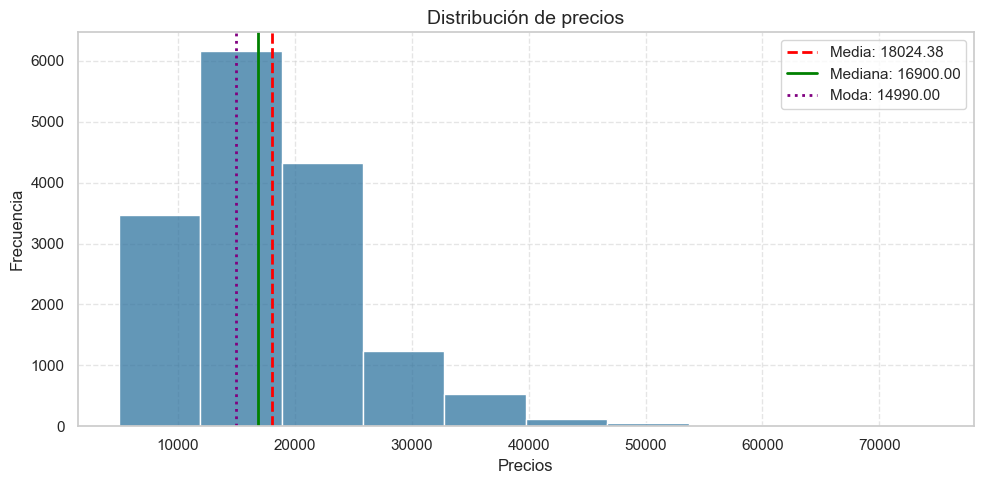

In [30]:

# Cálculo de medidas
media = np.mean(df['price'])
mediana = np.median(df['price'])
moda = stats.mode(df['price'], keepdims=True).mode[0]

# Datos 
print(f"Media: {media:.2f} mil pesos")
print(f"Mediana: {mediana:.2f} mil pesos")
print(f"Moda: {moda:.2f} mil pesos")
print("Arreglo:", df['price'])

# Visualización
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=10, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

# Estética
plt.title("Distribución de precios", fontsize=14)
plt.xlabel("Precios", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>

La media y la mediana son muy similares lo cual indica que la distribución de los precios es bastante simétrica, y no está fuertemente sesgada hacia un lado.
La moda es más baja, con un valor de 3 mil pesos lo que muestra que hay cierta concentración de precios menores al promedio, aunque la mayoría se agrupa alrededor de 4 mil pesos.

La muestra de 100 precios simulada refleja unos precios centrados en 4 mil pesos, pero con una tendencia ligera hacia valores menores, lo cual puede interpretarse como la existencia de un segmento con salarios bajos dentro de la población.

En el histograma, se observa una concentración importante de salarios alrededor de 4 mil pesos, pero también una presencia significativa de valores pequeños, lo que genera que la moda este abajo de la media y la mediana.

### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

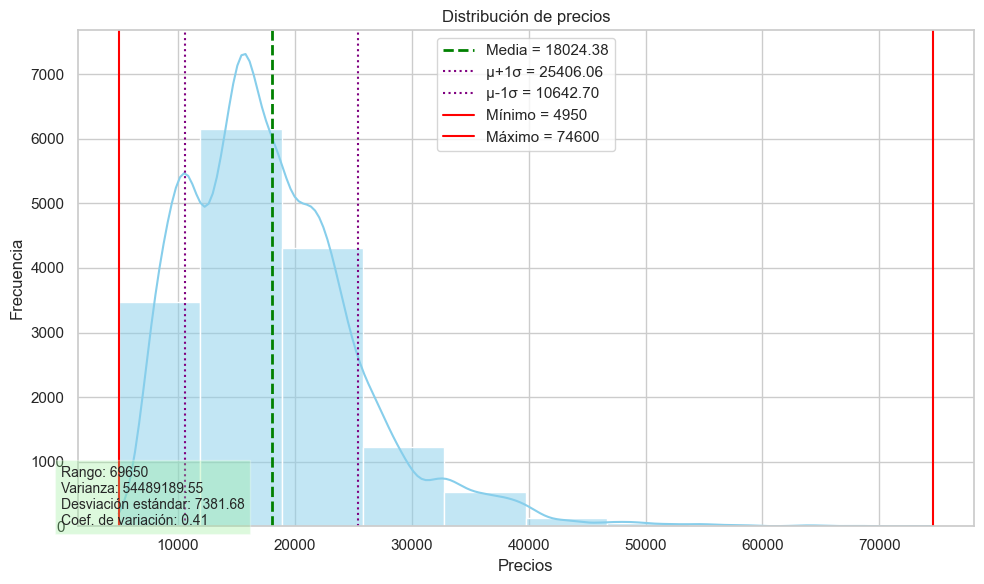

In [32]:
minimo = np.min(df['price'])
maximo = np.max(df['price'])
rango = maximo - minimo
varianza = np.var(df['price'], ddof=1)
desviacion = np.std(df['price'], ddof=1)
coef_var = desviacion / media

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=10, kde=True, color='skyblue')

# Líneas verticales
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

# Título y etiquetas
plt.title("Distribución de precios")
plt.xlabel("Precios")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
plt.text(0.7, 15, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>

- El rango muestra la amplitud total entre el precio más bajo y el más alto, en este caso entre 0 y 9.

- La Varianza mide la variabilidad global de los datos, los valores altos de la muestra simulada implica que los precios están más dispersos.

- La Desviación estándar indica cuánto, en promedio, se alejan los precios de la media. Para la simulación de 100 datos, en promedio, los precios se desvían ±1.98 mil pesos de la media (3.96).

- El Coeficiente de variación (CV) permite comparar la dispersión relativa; para un CV bajo (<20%) indica que los precios son bastante homogéneos respecto a la media. Para los datos simulados, este significa que la dispersión equivale a la mitad del valor promedio, lo que indica que los datos son moderadamente variables, no tan concentrados, pero tampoco totalmente dispersos.

### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

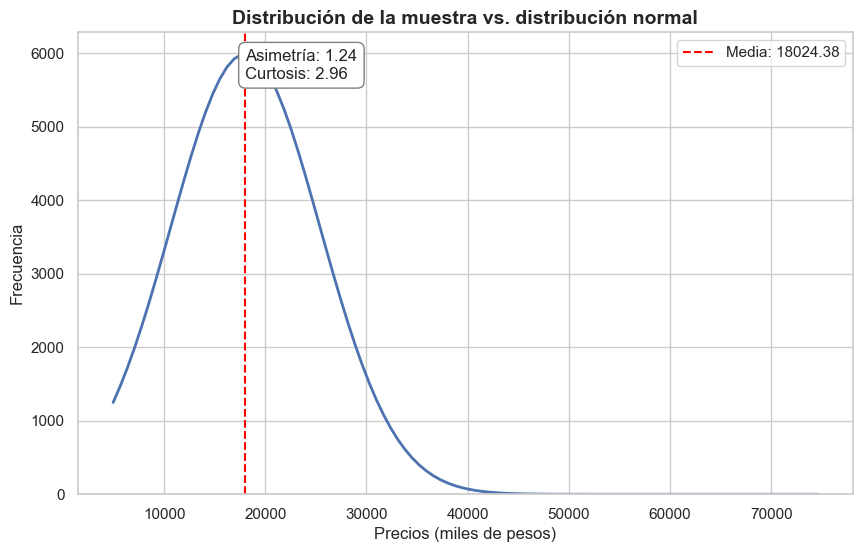

In [33]:
from scipy.stats import skew, kurtosis, norm

# Estilo visual
sns.set_theme(style="whitegrid")

# Cálculo de métricas
asimetria = skew(df['price'])
curtosis_valor = kurtosis(df['price'], fisher=True)

# Visualización con kde=false 
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=False, color="skyblue", bins=10, stat="frequency", alpha=0.6)

# Curva normal con la media y la desviación de los datos generados
x = np.linspace(min(df['price']), max(df['price']), 100)
plt.plot(x, norm.pdf(x, media, desviacion) * len(df['price']) * (max(df['price'])-min(df['price']))/10,"b-", lw=2) 

# Línea en la media
plt.axvline(media, color="red", linestyle="--", label=f"Media: {media:.2f}")

# Anotaciones 
plt.text(media+0.5, max(plt.gca().get_ylim())*0.9,
         f"Asimetría: {asimetria:.2f}\nCurtosis: {curtosis_valor:.2f}",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray"))

# Títulos
plt.title("Distribución de la muestra vs. distribución normal", fontsize=14, fontweight="bold")
plt.xlabel("Precios (miles de pesos)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


### <span style="color:red;"><strong>Interpretación</strong></span>

- La Asimetría tiene un valor de 0.43, al ser un valor positivo y cercano a cero, indica que la distribución presenta una ligera inclinación hacia la derecha. Esto significa que la mayoría de los valores se concentran alrededor de la media, pero existen algunos precios más altos que generan una pequeña cola extendida hacia los valores grandes. Sin embargo, al no superar 1, el sesgo es bajo y la distribución puede considerarse casi simétrica.

- La Curtosis tiene un valor de 0.04, valor que está muy próximo a 0, lo que implica que la distribución es mesocúrtica, es decir, tiene una distribución parecida a la de una distribución normal.

### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)


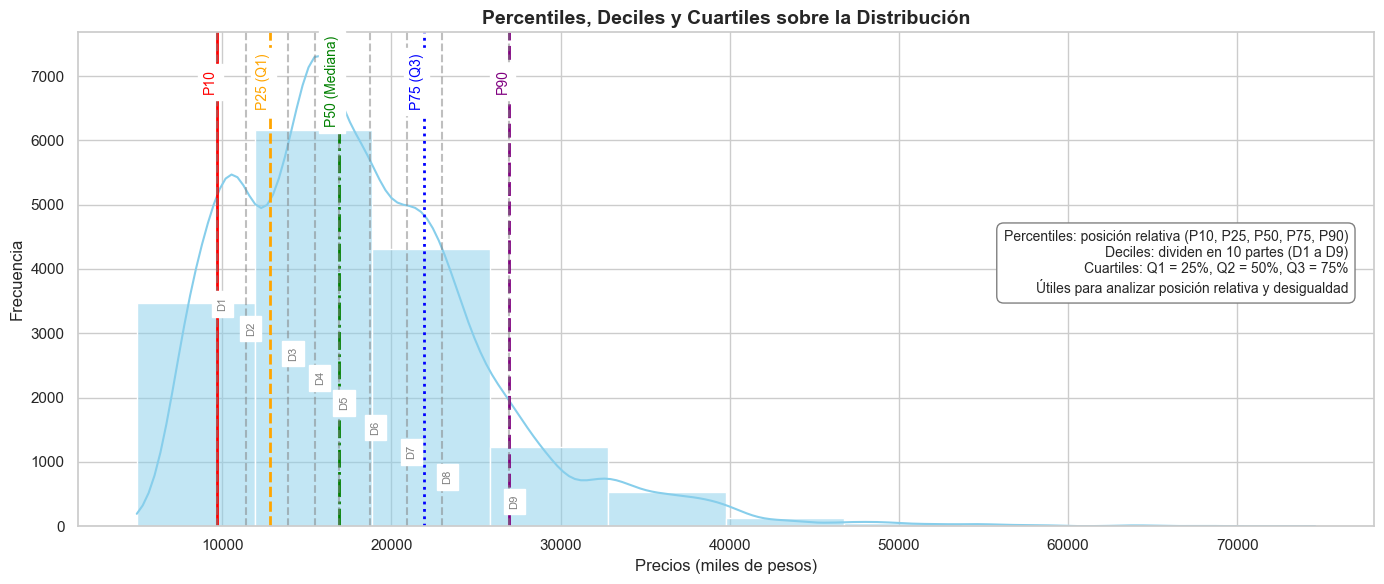

In [35]:
# Estilo visual
sns.set_theme(style="whitegrid")

# Cálculo de percentiles 
percentiles = {
    'P10': {'valor': np.percentile(df['price'], 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(df['price'], 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(df['price'], 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(df['price'], 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(df['price'], 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(df['price'], i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(14, 6))
sns.histplot(df['price'], kde=True, color='skyblue', bins=10)

# Líneas verticales para percentiles destacados
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'],
                linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.9, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             backgroundcolor='white')

# Líneas para deciles (D1 a D9)
for i, (etiqueta, valor) in enumerate(deciles.items(), start=1):
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.5)
    # Para que no se muestren encima uno de otro, muevo las etiquetas en diferentes alturas
    plt.text(valor, plt.ylim()[1]*(0.5 - i*0.05), etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='left',
             backgroundcolor='white')

# Recuadro 
texto = (
    "Percentiles: posición relativa (P10, P25, P50, P75, P90)\n"
    "Deciles: dividen en 10 partes (D1 a D9)\n"
    "Cuartiles: Q1 = 25%, Q2 = 50%, Q3 = 75%\n"
    "Útiles para analizar posición relativa y desigualdad"
    )
plt.text(0.98, 0.6, texto, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

# Títulos y estilo
plt.title("Percentiles, Deciles y Cuartiles sobre la Distribución", fontsize=14, fontweight='bold')
plt.xlabel("Precios (miles de pesos)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>


#### <span style="color:black;"><strong>Percetiles</strong></span>
- P10: El 10% de los precios está en 1 mil pesos o menos.
- P25 (Q1): El 25% de los precios está en 3 mil o menos.
- P50 (Mediana): La mitad de los precios está en 4 mil o menos, y la otra mitad en más de 4.
- P75 (Q3): El 75% de los precios está en 5 mil o menos.
- P90: El 90% de los precios está en 7 mil o menos; solo el 10% restante llega a 8 o 9.

Los datos de precios se concentran mayoritariamente entre 2 y 5, con unos pocos precios bajos (0–1) y algunos más altos (7–9). La distribución es bastante simétrica y no presenta colas extremas.


## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**. 
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  


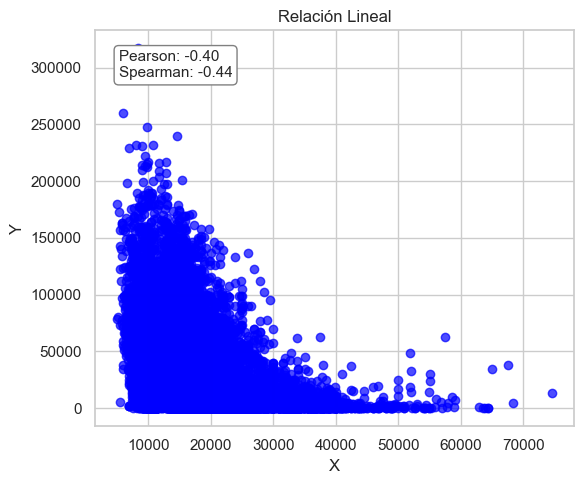

In [36]:
from scipy import stats


# Relación 
x = df['price']
y = df['km']

# Correlaciones
def calcular_correlaciones(x, y):
    pearson, _ = stats.pearsonr(x, y)
    spearman, _ = stats.spearmanr(x, y)
    return pearson, spearman

p1, s1 = calcular_correlaciones(x, y)

# Visualización comparativa
fig, ax = plt.subplots(figsize=(6, 5))

# Relación X1 vs Y1
ax.scatter(x, y, color="blue", alpha=0.7)
ax.set_title("Relación Lineal")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# Texto con coeficientes
texto = f"Pearson: {p1:.2f}\nSpearman: {s1:.2f}"
ax.text(0.05, 0.95, texto, transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>

- El coefiente Pearson tiene un valor de 0.82, lo que indica una correlación lineal fuerte y positiva entre x e y, es decir que cuando una variable aumenta, la otra también tiende a aumentar de forma bastante consistente y como es cercano a uno positivo, los puntos se agrupan de forma ascendente.

- El coefiente de Spearman tiene un valor 0.83, este mide la relación monótona entre las dos variables y también es fuerte y positiva, lo que confirma que no solo existe una relación lineal, sino también una relación monótona.

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Base de la cédula
base = 60082
np.random.seed(base)

# Muestra de 60 personas
n = 60

# Variables cualitativas 
niveles = ["Básico", "Medio", "Superior"]
internet = ["Sí", "No"]

nivel_educativo = np.random.choice(niveles, size=n, p=[0.3, 0.4, 0.3])   
acceso_internet = np.random.choice(internet, size=n, p=[0.7, 0.3])       

# DataFrame
df = pd.DataFrame({
    "Nivel educativo": nivel_educativo,
    "Acceso a internet": acceso_internet
})

# Tabla de contingencia
tabla = pd.crosstab(df["Nivel educativo"], df["Acceso a internet"])
print("Tabla de contingencia:")
print(tabla)

# Chi-cuadrado 
chi2, p, dof, esperados = chi2_contingency(tabla)
print("\nResultados Chi-cuadrado:")
print(f"Chi2 = {chi2:.2f}, p-valor = {p:.4f}, grados de libertad = {dof}")
print("Frecuencias esperadas:\n",pd.DataFrame(esperados, index=tabla.index, columns=tabla.columns), "\n")


# Visualización (mapa de calor)
plt.figure(figsize=(6,4))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Distribución conjunta: Nivel educativo vs Acceso a internet")
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>

Partiendo de la hipótesis nula de que: El acceso a internet y el nivel educativo son independientes y la alternativa: Existe asociación entre el acceso a internet y el nivel educativo.
- p-valor = 0.1109, como es mayor que 0.05, no hay evidencia suficiente para rechazar la hipótesis nula; lo que, estadísticamente, no podemos afirmar que exista relación significativa entre el nivel educativo y el acceso a internet en esta muestra de 60 personas.
  
Diferencias entre mustras observadas y esperadas:
- En Básico sin internet: se esperaban 4, pero hubo 7, más de lo esperado.
- En Medio sin internet: se esperaban 5, pero hubo 3, menos de lo esperado.
- En Superior los valores observados y esperados están muy cerca.